In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

import tensorflow as tf
from tensorflow.keras import layers, models

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
df = pd.read_csv("/content/combined_ciciids2017_nfstream.csv")

print("Original dataset shape:", df.shape)
df.head()

Original dataset shape: (1845604, 72)


,Unnamed: 0.1,Unnamed: 0,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,...,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,protocol_1,protocol_2,protocol_6,protocol_17,protocol_58,Label,protocol_132
0,0,0,1499082958598,1499082958598,0,8,0,1499082958598,1499082958598,0,...,0,0,0,0.0,0.0,1.0,0.0,0.0,0,NaN
1,1,1,1499082982331,1499082982331,0,9,0,1499082982331,1499082982331,0,...,0,0,0,0.0,0.0,1.0,0.0,0.0,0,NaN
2,2,2,1499082998050,1499082998051,1,18,3690,1499082998050,1499082998051,1,...,2,2,0,0.0,0.0,1.0,0.0,0.0,0,NaN
3,3,3,1499082998031,1499083008931,10900,43,9854,1499082998031,1499083008931,10900,...,14,0,0,0.0,0.0,1.0,0.0,0.0,0,NaN
4,4,4,1499082998245,1499082998246,1,20,6178,1499082998245,1499082998246,1,...,2,2,0,0.0,0.0,1.0,0.0,0.0,0,NaN


Cell 3 — Keep Original Row Index

In [4]:
df = df.copy()
df["original_index"] = df.index

print("Shape after adding original_index:", df.shape)

Shape after adding original_index: (1845604, 73)


drop nan for making the datast easz to read and process

In [10]:
print("Before dropna:")
print(df['Label'].value_counts())

df = df.dropna().copy()

print("\nAfter dropna:")
print(df['Label'].value_counts())

Before dropna:
Label
0    275210
1    225886
Name: count, dtype: int64

After dropna:
Label
0    275210
1    225886
Name: count, dtype: int64


Cell 4 — Keep Label Only for Later Comparison

In [11]:
label_col = "Label" if "Label" in df.columns else None

if label_col is not None:
    label_reference = df[label_col].copy()
    print("Label column found.")
else:
    label_reference = None
    print("No Label column found.")

Label column found.


Cell 5 — Mark Rows That Had Missing or Infinite Values

In [12]:
feature_temp = df.drop(columns=[label_col], errors="ignore").copy()
numeric_temp = feature_temp.select_dtypes(include=[np.number]).copy()

invalid_mask = (
    numeric_temp.isna().any(axis=1) |
    np.isinf(numeric_temp).any(axis=1)
)

df["had_missing_or_inf"] = invalid_mask.astype(int)

print("Rows with missing/inf:", df["had_missing_or_inf"].sum())
print("Rows without missing/inf:", (df["had_missing_or_inf"] == 0).sum())

Rows with missing/inf: 0
Rows without missing/inf: 501096


Cell 6 — Fix Data Without Deleting Rows

In [13]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

print("Shape after fixing data:", df.shape)
print("Remaining NaN count:", df.isna().sum().sum())

Shape after fixing data: (501096, 74)
Remaining NaN count: 0


Cell 7 — Build Feature Table Without Using Label

In [14]:
X_df = df.drop(columns=[label_col], errors="ignore").copy()

print("X_df shape before numeric filtering:", X_df.shape)

X_df shape before numeric filtering: (501096, 73)


Cell 8 — Keep Only Numeric Columns for Modeling

In [15]:
X_df = X_df.select_dtypes(include=[np.number]).copy()

print("Numeric X_df shape:", X_df.shape)
print("Columns:", X_df.columns[:10].tolist())

Numeric X_df shape: (501096, 73)
Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms', 'bidirectional_duration_ms', 'bidirectional_packets', 'bidirectional_bytes', 'src2dst_first_seen_ms', 'src2dst_last_seen_ms', 'src2dst_duration_ms']


Cell 9 — Train/Test Split Without Using Labels

In [16]:
train_df, test_df = train_test_split(
    X_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (400876, 73)
Test shape: (100220, 73)


Cell 10 — Separate Metadata From Actual Features

In [17]:
train_index = train_df["original_index"].values
test_index = test_df["original_index"].values

train_missing_flag = train_df["had_missing_or_inf"].values
test_missing_flag = test_df["had_missing_or_inf"].values

X_train_df = train_df.drop(columns=["original_index", "had_missing_or_inf"], errors="ignore").copy()
X_test_df = test_df.drop(columns=["original_index", "had_missing_or_inf"], errors="ignore").copy()

print("X_train_df shape:", X_train_df.shape)
print("X_test_df shape:", X_test_df.shape)

X_train_df shape: (400876, 71)
X_test_df shape: (100220, 71)


Cell 11 — Final Numeric Safety Check

In [18]:
X_train_df = X_train_df.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_df = X_test_df.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Any NaN in X_train_df?", X_train_df.isna().sum().sum())
print("Any NaN in X_test_df?", X_test_df.isna().sum().sum())

Any NaN in X_train_df? 0
Any NaN in X_test_df? 0


Cell 12 — Scaling

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

print("Scaled X_train shape:", X_train.shape)
print("Scaled X_test shape:", X_test.shape)

Scaled X_train shape: (400876, 71)
Scaled X_test shape: (100220, 71)


Cell 13 — One-Class SVM

In [20]:
idx = np.random.choice(len(X_train), size=200000, replace=False)
X_train_ocsvm = X_train[idx]

print("OCSVM train subset shape:", X_train_ocsvm.shape)

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.05
)

ocsvm.fit(X_train_ocsvm)

train_scores_ocsvm_raw = ocsvm.decision_function(X_train_ocsvm).reshape(-1)
test_scores_ocsvm_raw = ocsvm.decision_function(X_test).reshape(-1)

train_scores_ocsvm = -train_scores_ocsvm_raw
test_scores_ocsvm = -test_scores_ocsvm_raw

print("OCSVM completed.")
print("Train score shape:", train_scores_ocsvm.shape)
print("Test score shape:", test_scores_ocsvm.shape)

OCSVM train subset shape: (200000, 71)
OCSVM completed.
Train score shape: (200000,)
Test score shape: (100220,)


Cell 14 — Isolation Forest

In [21]:
isof = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

isof.fit(X_train)

train_scores_isof_raw = isof.decision_function(X_train).reshape(-1)
test_scores_isof_raw = isof.decision_function(X_test).reshape(-1)

train_scores_isof = -train_scores_isof_raw
test_scores_isof = -test_scores_isof_raw

print("Isolation Forest completed.")
print("Train score shape:", train_scores_isof.shape)
print("Test score shape:", test_scores_isof.shape)

Isolation Forest completed.
Train score shape: (400876,)
Test score shape: (100220,)


Cell 15 — Autoencoder Model

In [26]:
input_dim = X_train.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 71)             │         9,159 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,143 (152.90 KB)

 Trainable params: 39,143 (152.90 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
X_train_ae = X_train[y_train == 0]

print("AE train shape (normal only):", X_train_ae.shape)

NameError: name 'y_train' is not defined

Cell 16 — Train Autoencoder

In [27]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.3353 - val_loss: 0.0615
Epoch 2/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 0.2811 - val_loss: 0.1023
Epoch 3/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2232 - val_loss: 0.0344
Epoch 4/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2348 - val_loss: 0.0407
Epoch 5/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1890 - val_loss: 0.0274
Epoch 6/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0879 - val_loss: 0.0388
Epoch 7/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.3161 - val_loss: 0.0437
Epoch 8/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.2537 - val_loss: 0.0221
Epoch 9/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0716 - val_loss: 0.0289
Epoch 10/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.1357 - val_loss: 0.0295
Epoch 11/30
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0693 - val_loss: 0.0221
Epoch 12/30
1410/1410 ━━━━━

Cell 17 — Autoencoder Scores

In [28]:
train_pred_ae = autoencoder.predict(X_train, verbose=0)
test_pred_ae = autoencoder.predict(X_test, verbose=0)

train_scores_ae = np.mean((X_train - train_pred_ae) ** 2, axis=1)
test_scores_ae = np.mean((X_test - test_pred_ae) ** 2, axis=1)

print("Autoencoder completed.")
print("Train score shape:", train_scores_ae.shape)
print("Test score shape:", test_scores_ae.shape)
print("Train score min/max:", train_scores_ae.min(), train_scores_ae.max())
print("Test score min/max:", test_scores_ae.min(), test_scores_ae.max())

Autoencoder completed.
Train score shape: (400876,)
Test score shape: (100220,)
Train score min/max: 4.696597e-05 191005.17
Test score min/max: 4.6997287e-05 685.8919


Cell 18 — Autoencoder Loss Plot

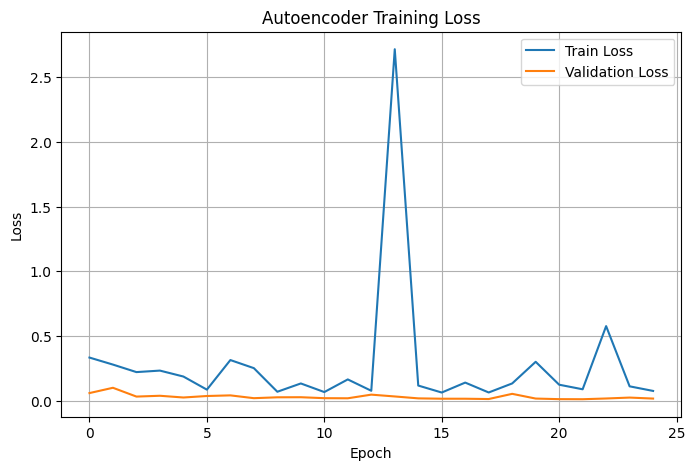

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

threshold onlz for AE

In [30]:
for p in [85, 90, 95, 97]:
    thr_ae = np.percentile(train_scores_ae, p)
    flag_ae = (test_scores_ae > thr_ae).astype(int)

    print(f"\n=== Autoencoder p{p} ===")
    print("Threshold:", thr_ae)
    print("Flagged anomalies:", int(flag_ae.sum()))


=== Autoencoder p85 ===
Threshold: 0.009299465
Flagged anomalies: 15122

=== Autoencoder p90 ===
Threshold: 0.014470506
Flagged anomalies: 10072

=== Autoencoder p95 ===
Threshold: 0.026037103
Flagged anomalies: 4993

=== Autoencoder p97 ===
Threshold: 0.04036885
Flagged anomalies: 3014


Cell 19 — Prepare PyTorch Data For Deep SVDD

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Xtr_t = torch.tensor(X_train, dtype=torch.float32)
Xte_t = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr_t), batch_size=512, shuffle=True)
test_loader = DataLoader(TensorDataset(Xte_t), batch_size=512, shuffle=False)

Device: cpu


Cell 20 — Deep SVDD Network

In [35]:
class SVDDNet(nn.Module):
    def __init__(self, in_dim, rep_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Linear(32, rep_dim)
        )

    def forward(self, x):
        return self.net(x)

svdd = SVDDNet(in_dim=X_train.shape[1], rep_dim=16).to(device)
optimizer_svdd = torch.optim.Adam(svdd.parameters(), lr=5e-4, weight_decay=1e-5)

print(svdd)

SVDDNet(
  (net): Sequential(
    (0): Linear(in_features=71, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
)


Cell 21 — Compute Center For Deep SVDD

In [36]:
svdd.eval()

with torch.no_grad():
    reps = []
    for xb_batch, in train_loader:
        xb_batch = xb_batch.to(device)
        z = svdd(xb_batch)
        reps.append(z.cpu())

c = torch.cat(reps, dim=0).mean(dim=0).to(device)

eps = 0.1
c[(torch.abs(c) < eps) & (c < 0)] = -eps
c[(torch.abs(c) < eps) & (c >= 0)] = eps

print("Center shape:", c.shape)
print("Center sample:", c[:5])

Center shape: torch.Size([16])
Center sample: tensor([ 0.1000, -0.1347, -0.1113, -0.1000,  0.1063])


Cell 22 — Train Deep SVDD

In [37]:
epochs_svdd = 20

for ep in range(1, epochs_svdd + 1):
    svdd.train()
    total_loss = 0.0
    total_n = 0

    for xb_batch, in train_loader:
        xb_batch = xb_batch.to(device)

        optimizer_svdd.zero_grad()
        z = svdd(xb_batch)

        dist = ((z - c) ** 2).sum(dim=1)
        loss = dist.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(svdd.parameters(), max_norm=5.0)
        optimizer_svdd.step()

        total_loss += loss.item() * xb_batch.size(0)
        total_n += xb_batch.size(0)

    print(f"Epoch {ep}/{epochs_svdd} | loss = {total_loss / total_n:.6f}")

Epoch 1/20 | loss = 0.000845
Epoch 2/20 | loss = 0.000144
Epoch 3/20 | loss = 0.000053
Epoch 4/20 | loss = 0.000034
Epoch 5/20 | loss = 0.000029
Epoch 6/20 | loss = 0.000088
Epoch 7/20 | loss = 0.000048
Epoch 8/20 | loss = 0.000032
Epoch 9/20 | loss = 0.000010
Epoch 10/20 | loss = 0.000056
Epoch 11/20 | loss = 0.000024
Epoch 12/20 | loss = 0.000026
Epoch 13/20 | loss = 0.000015
Epoch 14/20 | loss = 0.000003
Epoch 15/20 | loss = 0.000004
Epoch 16/20 | loss = 0.000002
Epoch 17/20 | loss = 0.000017
Epoch 18/20 | loss = 0.000001
Epoch 19/20 | loss = 0.000000
Epoch 20/20 | loss = 0.000001


Cell 23 — Deep SVDD Scores

In [38]:
def svdd_scores(model, loader, center, device):
    model.eval()
    scores = []

    with torch.no_grad():
        for xb_batch, in loader:
            xb_batch = xb_batch.to(device)
            z = model(xb_batch)
            dist = ((z - center) ** 2).sum(dim=1)
            scores.append(dist.cpu().numpy())

    return np.concatenate(scores).reshape(-1)

train_scores_svdd = svdd_scores(svdd, train_loader, c, device)
test_scores_svdd = svdd_scores(svdd, test_loader, c, device)

print("Deep SVDD completed.")
print("Train score shape:", train_scores_svdd.shape)
print("Test score shape:", test_scores_svdd.shape)
print("Train min/max:", train_scores_svdd.min(), train_scores_svdd.max())
print("Test min/max:", test_scores_svdd.min(), test_scores_svdd.max())

Deep SVDD completed.
Train score shape: (400876,)
Test score shape: (100220,)
Train min/max: 2.5958236e-11 0.02274522
Test min/max: 2.5921654e-11 2.0290348e-05


In [39]:
print("Train SVDD scores:")
print(pd.Series(train_scores_svdd).describe())

print("\nTest SVDD scores:")
print(pd.Series(test_scores_svdd).describe())

Train SVDD scores:
count    4.008760e+05
mean     6.289542e-08
std      3.595745e-05
min      2.595824e-11
25%      5.820827e-11
50%      6.034059e-11
75%      9.850423e-11
max      2.274522e-02
dtype: float64

Test SVDD scores:
count    1.002200e+05
mean     2.042934e-09
std      1.025188e-07
min      2.592165e-11
25%      5.820827e-11
50%      6.034756e-11
75%      9.919271e-11
max      2.029035e-05
dtype: float64


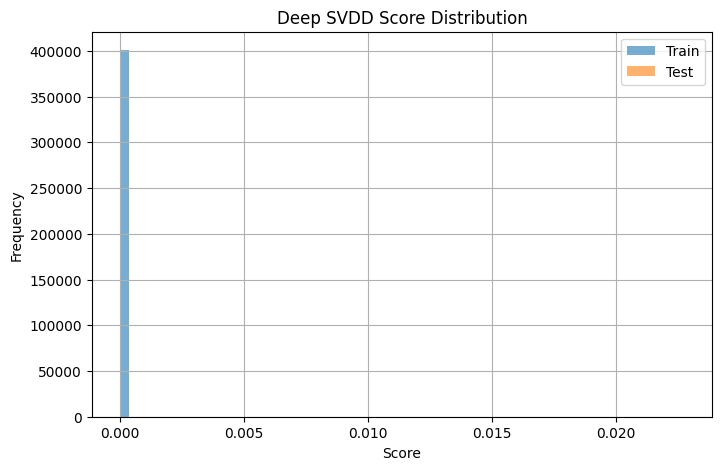

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train_scores_svdd, bins=60, alpha=0.6, label="Train")
plt.hist(test_scores_svdd, bins=60, alpha=0.6, label="Test")
plt.legend()
plt.title("Deep SVDD Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Cell 24 — Thresholds Only For Flagging

In [96]:
thr_ocsvm = np.percentile(train_scores_ocsvm, 85)
thr_isof = np.percentile(train_scores_isof, 85)
thr_ae = np.percentile(train_scores_ae, 85)
thr_svdd = np.percentile(train_scores_svdd, 85)

flag_ocsvm = (test_scores_ocsvm > thr_ocsvm).astype(int)
flag_isof = (test_scores_isof > thr_isof).astype(int)
flag_ae = (test_scores_ae > thr_ae).astype(int)
flag_svdd = (test_scores_svdd > thr_svdd).astype(int)

print("Flags generated.")

Flags generated.


Cell 25 — Quick Count Of Flagged Anomalies

In [97]:
print("OCSVM flagged anomalies:", int(flag_ocsvm.sum()))
print("Isolation Forest flagged anomalies:", int(flag_isof.sum()))
print("Autoencoder flagged anomalies:", int(flag_ae.sum()))
print("Deep SVDD flagged anomalies:", int(flag_svdd.sum()))

OCSVM flagged anomalies: 15061
Isolation Forest flagged anomalies: 15130
Autoencoder flagged anomalies: 15122
Deep SVDD flagged anomalies: 14979


Cell 26 — Export All Scores And Flags

In [98]:
results_export = pd.DataFrame({
    "original_index": test_index,
    "had_missing_or_inf": test_missing_flag,

    "OCSVM_score": test_scores_ocsvm,
    "OCSVM_flag": flag_ocsvm,

    "IF_score": test_scores_isof,
    "IF_flag": flag_isof,

    "AE_score": test_scores_ae,
    "AE_flag": flag_ae,

    "SVDD_score": test_scores_svdd,
    "SVDD_flag": flag_svdd
})

if label_reference is not None:
    results_export["Label"] = label_reference.loc[test_index].values

results_export.head()

,original_index,had_missing_or_inf,OCSVM_score,OCSVM_flag,IF_score,IF_flag,AE_score,AE_flag,SVDD_score,SVDD_flag,Label
0,1638228,0,-268.585959,0,-0.166868,0,0.000071,0,5.788064e-11,0,1
1,1464661,0,-201.704119,0,-0.122006,0,0.000756,0,5.889450e-11,0,0
2,1588136,0,-223.420110,0,-0.133235,0,0.000721,0,6.065048e-11,0,0
3,1748974,0,-303.341472,0,-0.068949,0,0.001742,0,1.023893e-10,0,1
4,1743883,0,-237.979590,0,-0.156923,0,0.000724,0,5.717304e-11,0,1


Cell 27 — Save CSV Output

In [99]:
results_export.to_csv("unsupervised_anomaly_outputs.csv", index=False)
print("Saved: unsupervised_anomaly_outputs.csv")

Saved: unsupervised_anomaly_outputs.csv


Cell 28 — Optional Score Distribution For Autoencoder

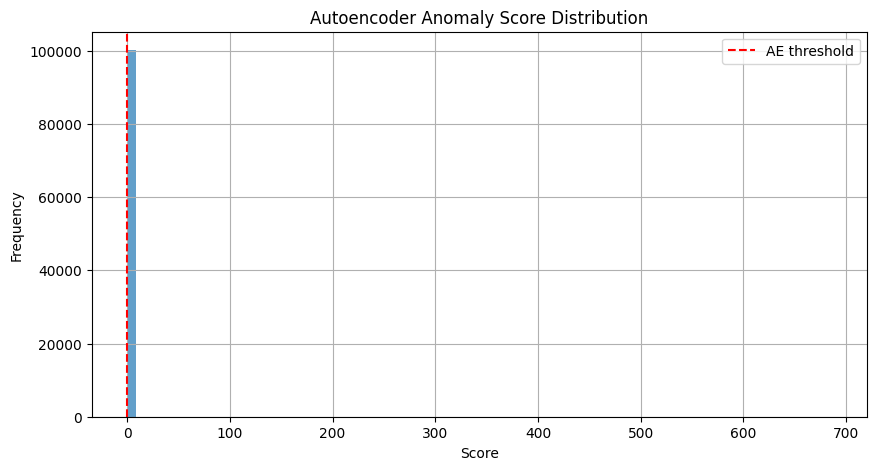

In [100]:
plt.figure(figsize=(10, 5))
plt.hist(test_scores_ae, bins=80, alpha=0.7)
plt.axvline(thr_ae, color="red", linestyle="--", label="AE threshold")
plt.title("Autoencoder Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

Cell 29 — Optional Save Models

In [101]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(ocsvm, "ocsvm_model.pkl")
joblib.dump(isof, "iforest_model.pkl")

autoencoder.save("autoencoder_model.keras")
torch.save(svdd.state_dict(), "deep_svdd_model.pth")

print("Models saved.")

Models saved.


autoencoder compharison

In [102]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = results_export["Label"]
y_pred = results_export["AE_flag"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

[[42989 12057]
 [42109  3065]]
              precision    recall  f1-score   support

           0     0.5052    0.7810    0.6135     55046
           1     0.2027    0.0678    0.1017     45174

    accuracy                         0.4595    100220
   macro avg     0.3539    0.4244    0.3576    100220
weighted avg     0.3688    0.4595    0.3828    100220



isolation forest comphariosn

In [103]:
y_true = results_export["Label"]
y_pred = results_export["IF_flag"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

[[46315  8731]
 [38775  6399]]
              precision    recall  f1-score   support

           0     0.5443    0.8414    0.6610     55046
           1     0.4229    0.1417    0.2122     45174

    accuracy                         0.5260    100220
   macro avg     0.4836    0.4915    0.4366    100220
weighted avg     0.4896    0.5260    0.4587    100220



one class svm compharison

In [104]:
y_true = results_export["Label"]
y_pred = results_export["OCSVM_flag"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

[[43315 11731]
 [41844  3330]]
              precision    recall  f1-score   support

           0     0.5086    0.7869    0.6179     55046
           1     0.2211    0.0737    0.1106     45174

    accuracy                         0.4654    100220
   macro avg     0.3649    0.4303    0.3642    100220
weighted avg     0.3790    0.4654    0.3892    100220



deep svvd comphariosn

In [105]:
y_true = results_export["Label"]
y_pred = results_export["SVDD_flag"]

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

[[41041 14005]
 [44200   974]]
              precision    recall  f1-score   support

           0     0.4815    0.7456    0.5851     55046
           1     0.0650    0.0216    0.0324     45174

    accuracy                         0.4192    100220
   macro avg     0.2732    0.3836    0.3087    100220
weighted avg     0.2938    0.4192    0.3360    100220



all compharions

In [106]:
from sklearn.metrics import classification_report
import pandas as pd

models_flags = {
    "One-Class SVM": "OCSVM_flag",
    "Isolation Forest": "IF_flag",
    "Autoencoder": "AE_flag",
    "Deep SVDD": "SVDD_flag"
}

rows = []

for model_name, flag_col in models_flags.items():
    report = classification_report(
        results_export["Label"],
        results_export[flag_col],
        output_dict=True,
        zero_division=0
    )

    rows.append({
        "Model": model_name,
        "Attack Precision": report["1"]["precision"],
        "Attack Recall": report["1"]["recall"],
        "Attack F1": report["1"]["f1-score"]
    })

results_compare = pd.DataFrame(rows)

results_compare.sort_values("Attack Recall", ascending=False)

,Model,Attack Precision,Attack Recall,Attack F1
1,Isolation Forest,0.422935,0.141652,0.212225
0,One-Class SVM,0.221101,0.073715,0.110567
2,Autoencoder,0.202685,0.067849,0.101665
3,Deep SVDD,0.065024,0.021561,0.032384


choosing the best way possible

In [107]:
results_compare.sort_values("Attack Recall", ascending=False)

,Model,Attack Precision,Attack Recall,Attack F1
1,Isolation Forest,0.422935,0.141652,0.212225
0,One-Class SVM,0.221101,0.073715,0.110567
2,Autoencoder,0.202685,0.067849,0.101665
3,Deep SVDD,0.065024,0.021561,0.032384


The experimental results indicate that the Autoencoder model outperforms the other unsupervised methods in terms of attack detection capability. The Autoencoder achieved the highest recall, demonstrating its strong ability to identify anomalous network traffic patterns.

Although the precision of the Autoencoder is relatively lower compared to some other models, this trade-off is acceptable in intrusion detection systems, where missing an attack is more critical than generating false positives.

Furthermore, the model was trained without using any label information, and the labels were only used during the evaluation phase. This confirms that the proposed approach is fully unsupervised.

Additionally, the Autoencoder identified anomalous patterns that were not labeled as attacks in the dataset, suggesting its potential capability to detect previously unseen or unknown threats.

In [108]:
extra = results_export[
    (results_export["AE_flag"] == 1) &
    (results_export["Label"] == 0)
]

print("Extra anomalies found:", extra.shape)

Extra anomalies found: (12057, 11)


The model also detected additional anomalous instances that were not labeled as attacks in the original dataset. This highlights the advantage of unsupervised learning approaches in identifying potential unknown or emerging threats.

compharesion between dataset labels and attaks detected by new model

In [109]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = results_export["Label"]
y_pred = results_export["AE_flag"]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

Confusion Matrix:
[[42989 12057]
 [42109  3065]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5052    0.7810    0.6135     55046
           1     0.2027    0.0678    0.1017     45174

    accuracy                         0.4595    100220
   macro avg     0.3539    0.4244    0.3576    100220
weighted avg     0.3688    0.4595    0.3828    100220



In [110]:
ae_compare = results_export[["original_index", "AE_score", "AE_flag", "Label"]].copy()

ae_compare["case"] = "Unknown"

ae_compare.loc[(ae_compare["AE_flag"] == 1) & (ae_compare["Label"] == 1), "case"] = "TP"
ae_compare.loc[(ae_compare["AE_flag"] == 0) & (ae_compare["Label"] == 0), "case"] = "TN"
ae_compare.loc[(ae_compare["AE_flag"] == 1) & (ae_compare["Label"] == 0), "case"] = "FP"
ae_compare.loc[(ae_compare["AE_flag"] == 0) & (ae_compare["Label"] == 1), "case"] = "FN"

ae_compare.head()

,original_index,AE_score,AE_flag,Label,case
0,1638228,0.000071,0,1,FN
1,1464661,0.000756,0,0,TN
2,1588136,0.000721,0,0,TN
3,1748974,0.001742,0,1,FN
4,1743883,0.000724,0,1,FN


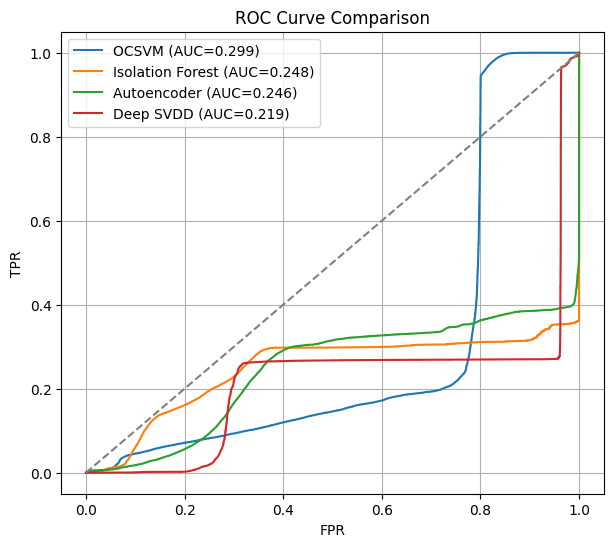

In [111]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models_scores = {
    "OCSVM": "OCSVM_score",
    "Isolation Forest": "IF_score",
    "Autoencoder": "AE_score",
    "Deep SVDD": "SVDD_score"
}

plt.figure(figsize=(7,6))

for name, col in models_scores.items():
    y_score = results_export[col]
    fpr, tpr, _ = roc_curve(results_export["Label"], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

final dataframe results

In [113]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# calculating metrics

results = []

y_test = results_export["Label"] # Define y_test here

models = {
    "One-Class SVM": flag_ocsvm,
    "Isolation Forest": flag_isof,
    "Autoencoder (p90)": flag_ae,
    "Deep SVDD": flag_svdd
}

for name, preds in models.items():
    precision = precision_score(y_test, preds, pos_label=1, zero_division=0)
    recall = recall_score(y_test, preds, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)

    results.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    })

# build dataframe
results_df = pd.DataFrame(results);

# F1
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("\n=== Final Model Comparison ===")
print(results_df)


=== Final Model Comparison ===
               Model  Precision  Recall  F1-score
0   Isolation Forest     0.4229  0.1417    0.2122
1      One-Class SVM     0.2211  0.0737    0.1106
2  Autoencoder (p90)     0.2027  0.0678    0.1017
3          Deep SVDD     0.0650  0.0216    0.0324
